In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RAW_DIR = Path("../data/raw")
customers = pd.read_csv(RAW_DIR / "customers.csv", na_values=["", "NA", "N/A", "-", ".", "null", "NULL"])
support = pd.read_csv(RAW_DIR / "customer_support.csv", na_values=["", "NA", "N/A", "-", ".", "null", "NULL"])
mkt = pd.read_csv(RAW_DIR / "marketing_touchpoints.csv", na_values=["", "NA", "N/A", "-", ".", "null", "NULL"])

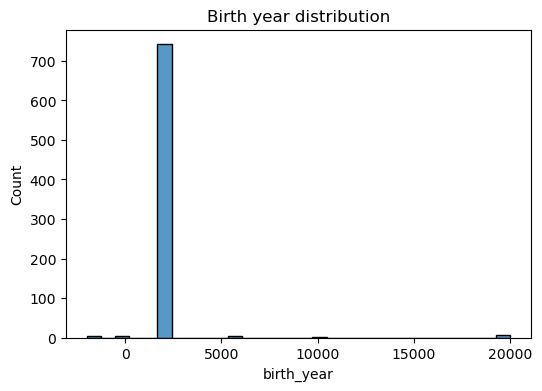

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(customers["birth_year"], bins=30, kde=False)
plt.title("Birth year distribution")
plt.show()

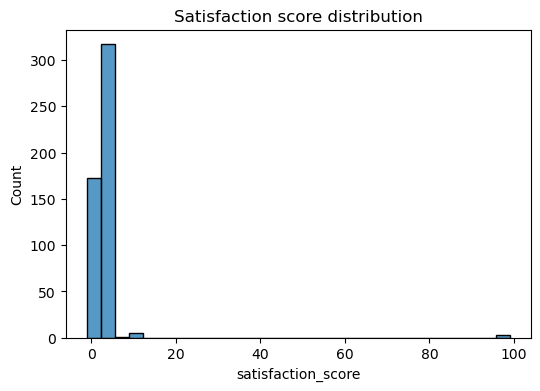

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(support["satisfaction_score"], bins=30, kde=False)
plt.title("Satisfaction score distribution")
plt.show()

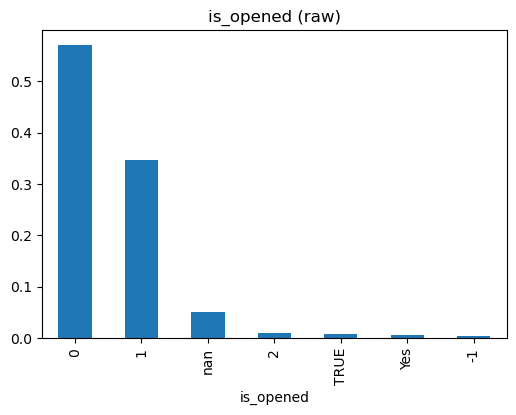

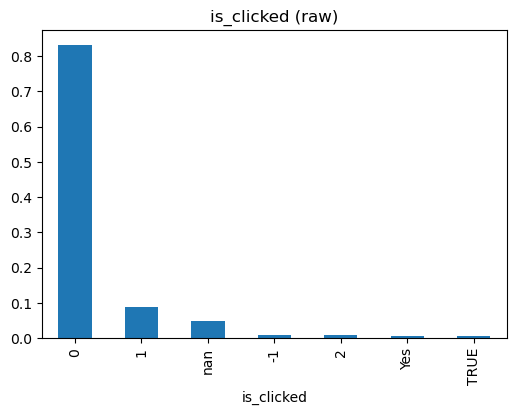

In [7]:
mkt["is_opened"].value_counts(dropna=False)
mkt["is_clicked"].value_counts(dropna=False)

plt.figure(figsize=(6,4))
mkt["is_opened"].value_counts(normalize=True, dropna=False).plot(kind="bar")
plt.title("is_opened (raw)")
plt.show()

plt.figure(figsize=(6,4))
mkt["is_clicked"].value_counts(normalize=True, dropna=False).plot(kind="bar")
plt.title("is_clicked (raw)")
plt.show()

### Cleaning rules derived from EDA

- `is_opened`: Standardize binary values by mapping {1, '1', 'Yes', 'TRUE'} to 1
  and {0, '0', 'No', 'FALSE'} to 0; treat other values (2, -1, unknown strings)
  as missing.
- `is_clicked`: Apply the same mapping as `is_opened` and enforce the rule
  `is_clicked <= is_opened` by setting `is_opened = 1` whenever `is_clicked = 1`.
- `birth_year`: Keep only plausible years (1900–2010); convert invalid values
  such as 0, negatives, 5000, 10000, 20000 to missing, then impute with the
  median and add a missingness flag.
- `satisfaction_score`: Keep only values in [1, 5]; convert 0, -1, 10, 99 to
  missing; allow missing scores for `Pending` tickets.
- `channel`: Normalize known channels and map invalid values such as `Pigeon`,
  `Fax`, `null` to `Unknown`.
- `date columns`: Parse all date fields with coercion, turning malformed dates
  like `0000-00-00` into missing.